In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Conv2DTranspose, Reshape
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
# Load and preprocess MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0


In [3]:
# Convert labels to categorical (one-hot encoding)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## Encoder Architecture:

- Three convolutional layers are used with increasing filter sizes (32, 64, 128), each followed by batch normalization to stabilize and accelerate training.
- After each convolutional layer, a max-pooling layer is added to reduce the spatial dimensions.
- Dropout layers are added after each max-pooling layer to prevent overfitting by randomly dropping some neurons during training.
- The output from the convolutional layers is flattened to create the encoded representation.

In [4]:
# Define the encoder model
input_img = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)
encoded = Flatten()(x)


## Decoder Architecture:

- The decoder starts with a dense layer that maps the encoded representation to a larger dense layer.
- The dense layer is reshaped to match the dimensions expected by the transposed convolutional layers.
- Three transposed convolutional layers are used to upsample the features back to the original image dimensions.
- The output of the decoder is flattened and passed through a final dense layer with 10 units and a softmax activation function for classification.

In [5]:
# Define the decoder model
x = Dense(128, activation='relu')(encoded)
x = Dropout(0.5)(x)
x = Dense(28 * 28 * 32, activation='relu')(x)
x = Reshape((28, 28, 32))(x)
x = Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
decoded = Flatten()(x)
decoded = Dense(10, activation='softmax')(decoded)

- The model is compiled with the Adam optimizer and categorical cross-entropy loss.
- Accuracy, precision, and recall are used as metrics.
- Early stopping is implemented to monitor the validation loss and stop training if it does not improve for 3 consecutive epochs.

In [6]:
# Define the model
model = Model(inputs=input_img, outputs=decoded)

# Compile the model
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy', 
                       tf.keras.metrics.Precision(name='precision'), 
                       tf.keras.metrics.Recall(name='recall')])

In [7]:
# Implement early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [8]:
# Train the model
history = model.fit(x_train, y_train, 
                    epochs=50, 
                    validation_data=(x_test, y_test), 
                    callbacks=[early_stopping])

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 309s 163ms/step - accuracy: 0.7543 - loss: 1.5362 - precision: 0.7793 - recall: 0.7323 - val_accuracy: 0.9775 - val_loss: 0.0866 - val_precision: 0.9811 - val_recall: 0.9742
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 298s 159ms/step - accuracy: 0.9546 - loss: 0.1745 - precision: 0.9617 - recall: 0.9467 - val_accuracy: 0.9857 - val_loss: 0.0519 - val_precision: 0.9871 - val_recall: 0.9840
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 301s 161ms/step - accuracy: 0.9719 - loss: 0.1032 - precision: 0.9764 - recall: 0.9674 - val_accuracy: 0.9858 - val_loss: 0.0853 - val_precision: 0.9868 - val_recall: 0.9850
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 280s 149ms/step - accuracy: 0.9743 - loss: 0.0902 - precision: 0.9786 - recall: 0.9712 - val_accuracy: 0.9920 - val_loss: 0.0396 - val_precision: 0.9927 - val_recall: 0.9918
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 280s 149ms/step - accuracy: 0.9785 - loss: 0.0784 - precision: 0.9822 - recall: 0.9756 - val_a

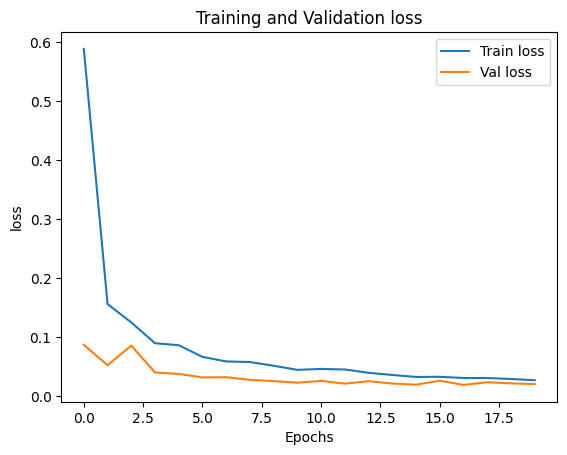

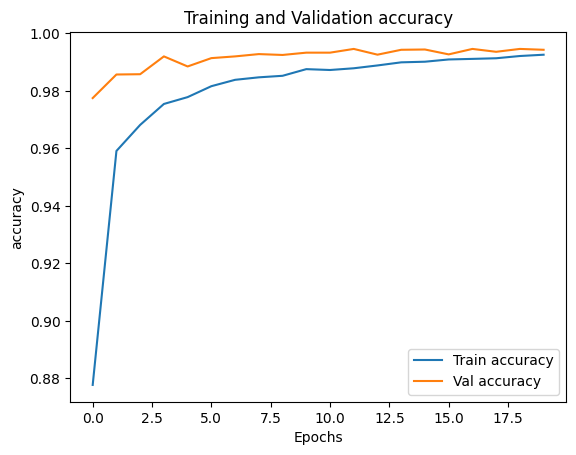

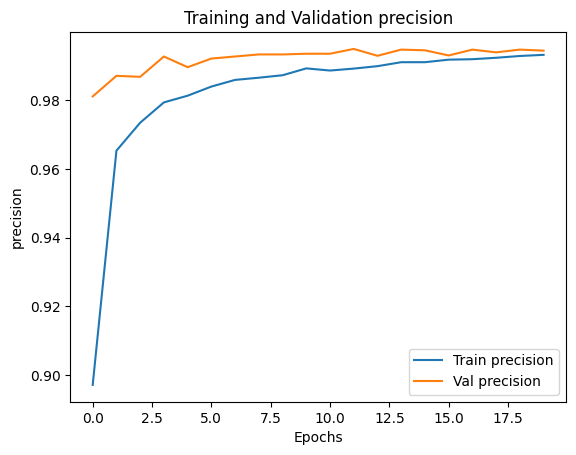

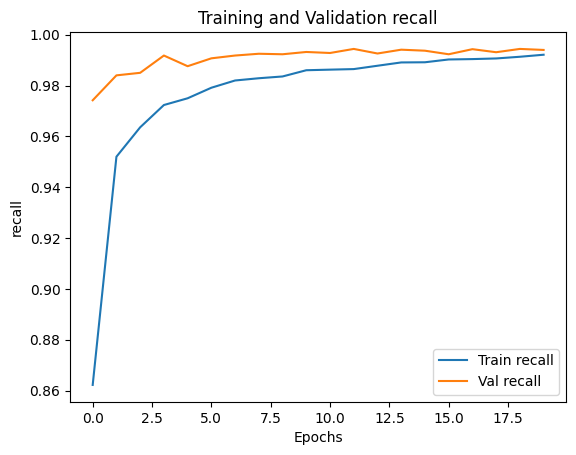

In [9]:
# Plotting training & validation metrics
def plot_metrics(history):
    metrics = ['loss', 'accuracy', 'precision', 'recall']
    for metric in metrics:
        plt.plot(history.history[metric], label=f'Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}')
        plt.title(f'Training and Validation {metric}')
        plt.xlabel('Epochs')
        plt.ylabel(metric)
        plt.legend()
        plt.show()

plot_metrics(history)

In [10]:
# Evaluate the model
results = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")
print(f"Test Precision: {results[2]}")
print(f"Test Recall: {results[3]}")

Test Loss: 0.01847936026751995
Test Accuracy: 0.9945999979972839
Test Precision: 0.9946978688240051
Test Recall: 0.9943000078201294


In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25088)          │     3,236,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 28, 28, 128)    │        36,992 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 64)     │           25

 Total params: 11,573,824 (44.15 MB)

 Trainable params: 3,857,642 (14.72 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 7,715,286 (29.43 MB)

In [12]:
model.save("EncoderDecoder.keras")